<a href="https://colab.research.google.com/github/akuntugasrapon/RafkiAhmadPagamanda_2311533016_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [4]:
df = pd.read_csv("Breast_cancer_data.csv")

df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [6]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


In [7]:
X = df.drop(columns=['diagnosis'])

y = df['diagnosis']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=16
)

MODEL 1 : LOGISTIC REGRESSION TANPA SCALING

In [9]:
model_no_scale = LogisticRegression(max_iter=10000)

model_no_scale.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [10]:
y_pred_no_scale = model_no_scale.predict(X_test)

In [11]:
print("=== MODEL TANPA SCALING ===")

print("Accuracy :", accuracy_score(y_test, y_pred_no_scale))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_no_scale))

print("\nClassification Report")
print(classification_report(y_test, y_pred_no_scale))

=== MODEL TANPA SCALING ===
Accuracy : 0.9005847953216374

Confusion Matrix
[[56  9]
 [ 8 98]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        65
           1       0.92      0.92      0.92       106

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



MODEL 2 : LOGISTIC REGRESSION DENGAN SCALING

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [13]:
model_scaled = LogisticRegression(max_iter=10000)

model_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [14]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

In [15]:
print("=== MODEL DENGAN SCALING ===")

print("Accuracy :", accuracy_score(y_test, y_pred_scaled))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_scaled))

print("\nClassification Report")
print(classification_report(y_test, y_pred_scaled))

=== MODEL DENGAN SCALING ===
Accuracy : 0.9415204678362573

Confusion Matrix
[[ 59   6]
 [  4 102]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        65
           1       0.94      0.96      0.95       106

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



PERCOBAAN THRESHOLD

In [16]:
y_prob = model_scaled.predict_proba(X_test_scaled)[:,1]

In [17]:
threshold = 0.4

y_pred_04 = (y_prob >= threshold).astype(int)

print("=== THRESHOLD 0.4 ===")

print("Accuracy :", accuracy_score(y_test, y_pred_04))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_04))

print("\nClassification Report")
print(classification_report(y_test, y_pred_04))

=== THRESHOLD 0.4 ===
Accuracy : 0.9532163742690059

Confusion Matrix
[[ 58   7]
 [  1 105]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.89      0.94        65
           1       0.94      0.99      0.96       106

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



In [18]:
threshold = 0.5

y_pred_05 = (y_prob >= threshold).astype(int)

print("=== THRESHOLD 0.5 ===")

print("Accuracy :", accuracy_score(y_test, y_pred_05))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_05))

print("\nClassification Report")
print(classification_report(y_test, y_pred_05))

=== THRESHOLD 0.5 ===
Accuracy : 0.9415204678362573

Confusion Matrix
[[ 59   6]
 [  4 102]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        65
           1       0.94      0.96      0.95       106

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



In [19]:
threshold = 0.6

y_pred_06 = (y_prob >= threshold).astype(int)

print("=== THRESHOLD 0.6 ===")

print("Accuracy :", accuracy_score(y_test, y_pred_06))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_06))

print("\nClassification Report")
print(classification_report(y_test, y_pred_06))

=== THRESHOLD 0.6 ===
Accuracy : 0.935672514619883

Confusion Matrix
[[61  4]
 [ 7 99]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        65
           1       0.96      0.93      0.95       106

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.93       171
weighted avg       0.94      0.94      0.94       171



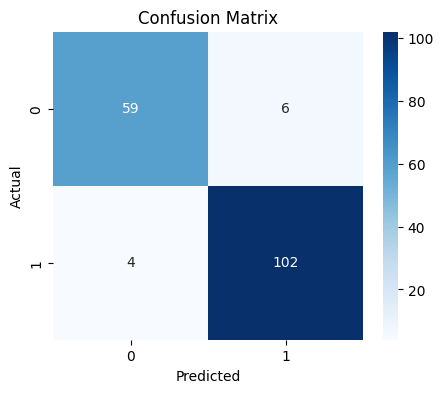

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_scaled)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.show()